## Лабораторная работа №8. Конечно-разностные схемы.


### Гиперболические задачи

$$
\frac{\partial^2 u}{\partial t^2} = a^2 \frac{\partial^2 u}{\partial x^2}
$$

Условие устойчивости Куранта (CFL)
   $$\sigma = \frac{a \tau}{h} \leq 1$$

### Параболический тип

Уравнение теплопроводности:

$$
\frac{\partial u}{\partial t} = a^2 \frac{\partial^2 u}{\partial x^2}
$$

Решаются приемущественно неявными схемами:

$$
\frac{u_j^{n+1} - u_j^n}{\Delta t} = a^2 \frac{u_{j+1}^{n+1} - 2u_j^{n+1} + u_{j-1}^{n+1}}{\Delta x^2}
$$

Где на каждом шаге нужно решать систему линейных уравнений (прогонка в 1D, итерации в 2D/3D).

**Схема Лакса–Вендорфа**
$$
u_j^{n+1} = u_j^n - \frac{a\tau}{2h} \left( u_{j+1}^n - u_{j-1}^n \right) + \frac{a^2\tau^2}{2h^2} \left( u_{j+1}^n - 2u_j^n + u_{j-1}^n \right)
$$

**Схема Куранта–Изаксона–Риса (Courant–Isaacson–Rees)**
$$
u_j^{n+1} = u_j^n - \frac{\tau}{2h} \left[ a \left( u_{j+1}^n - u_{j-1}^n \right) - |a| \left( u_{j+1}^n - 2u_j^n + u_{j-1}^n \right) \right]
$$


**Схема Уорминга–Кутлера–Ломакса (Warming–Kutler–Lomax)**
$$
u_j^{n+1} = u_j^n - \frac{a\tau}{h} \left( u_j^n - u_{j-1}^n \right) - \frac{a\tau}{2h} \left( 1 - \frac{a\tau}{h} \right) \left( u_j^n - 2u_{j-1}^n + u_{j-2}^n \right)
$$

#### Задача 14

Уравнение Бюргерса, описывающее перенос и диффузию загрязнений в воздухе:

$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = \mu \frac{\partial^2 u}{\partial x^2}$$

$$u(0, t) = U, u(L, t) = 0, u(x, 0) = 0$$

$$x \in [0, L], t \in [0, T]$$
где $u$ - концентрация некоторого вещества, $\mu$ - коэффициент диффузии, $c$ - постоянная скорость потока.

Точное решение при $u(x, 0) = sin(k x)$:
$$u(x, t) = exp(- k^2 \mu t) sin (k(x - ct))$$

In [29]:
import numpy as np

from comp_math.finite_difference.burgers.burgers_problem import BurgersProblem
from comp_math.finite_difference.burgers.burgers_solver import BurgersSolver

from comp_math.finite_difference.imagine_solution import plot_heatmap, plot_profile

import matplotlib.pyplot as plt

In [103]:
def U0t(t: float) -> float:
    return 0.0

def ULt(t: float) -> float:
    return 0.0

k1 = np.pi * 2.0
k2 = 1.0

def Ux0(x: float) -> float:
    return k2 * np.sin(x * k1)

T = 0.3
L = 1.0
c = 1.0
mu = 1.0

tau = 0.001
h = 0.001

problem14 = BurgersProblem(U0t=U0t, ULt=ULt, Ux0=Ux0, T=T, L=L, c=c, mu=mu)

burgersSolver = BurgersSolver(problem14)

u = burgersSolver.solve(tau, h)

In [104]:
def get_exact_u1(tau, h, T, L, c, mu):
    t_num = int(T / tau)
    x_num = int(L / h)
    exact_u1 = np.zeros(shape=(t_num, x_num))
    for n in range(t_num):
        for j in range(x_num):
            t = n * tau
            x = j * h
            exact_u1[n][j] = k2 * np.exp(- k1 ** 2 * mu * t) * np.sin(k1 * (x - c * t))
    return exact_u1

exact_u = get_exact_u1(tau, h, T, L, c, mu)

def allclose_2d(a, b, eps=1e-2):
    return np.allclose(a, b, rtol=0, atol=eps)

# print("Checking result: ", allclose_2d(exact_u1, u))
# print("Shapes:", exact_u1.shape, u.shape)

def print_max_diff(exact_u, u, tau, h):
    t_idx, x_idx = np.unravel_index(np.argmax(np.abs(exact_u - u)), np.abs(exact_u - u).shape)
    print("Max diff:", np.max(np.abs(exact_u - u)), " at point (t:", t_idx * tau, ", x:", x_idx * h, ")")

print_max_diff(exact_u, u, tau, h)

Max diff: 0.06475873059465255  at point (t: 0.024 , x: 0.998 )


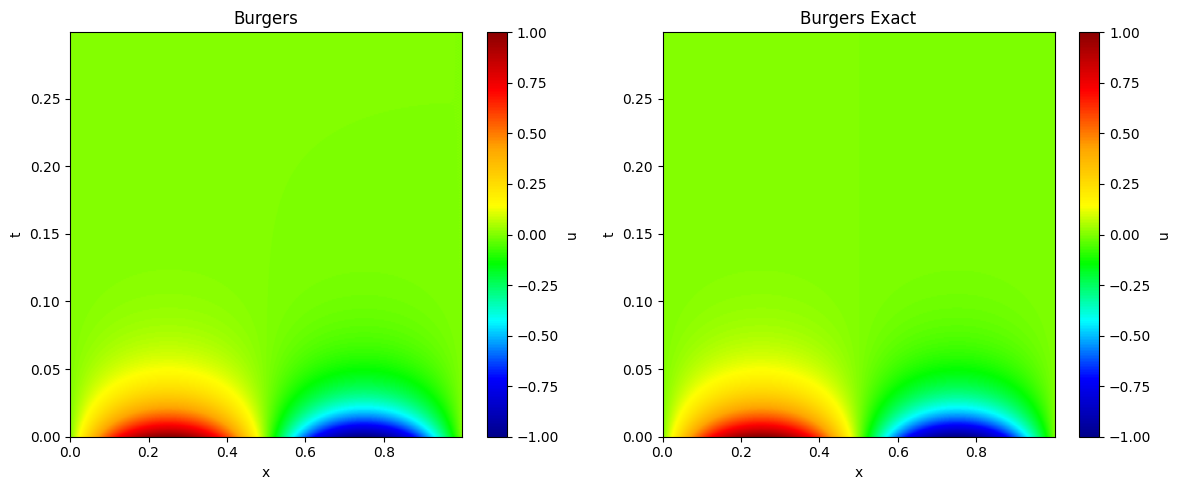

In [114]:
x = np.arange(0, L , h)
t = np.arange(0, T , tau)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes_flat = axes.flatten()

plot_heatmap(u, x, t, title="Burgers", cmap="thermal", ax=axes_flat[0])
plot_heatmap(exact_u, x, t, title="Burgers Exact", cmap="thermal", ax=axes_flat[1])

plt.tight_layout()
plt.show()


<Axes: title={'center': 'Профили в разные моменты времени'}, xlabel='x', ylabel='u'>

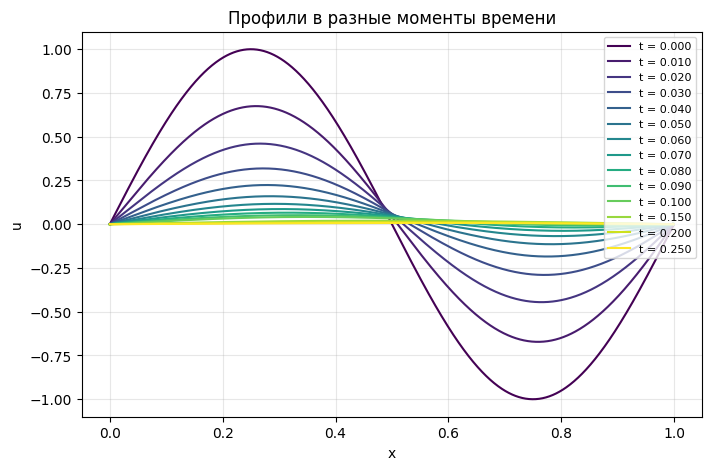

In [106]:
plot_profile(u, x, t, [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250])

Max diff: 0.06475873059465255  at point (t: 0.024 , x: 0.998 )
Max diff: 0.11981746998776932  at point (t: 0.048 , x: 0.998 )
Max diff: 0.45071990332158196  at point (t: 0.16 , x: 0.999 )
Max diff: 0.9902021994614036  at point (t: 0.249 , x: 0.9999 )


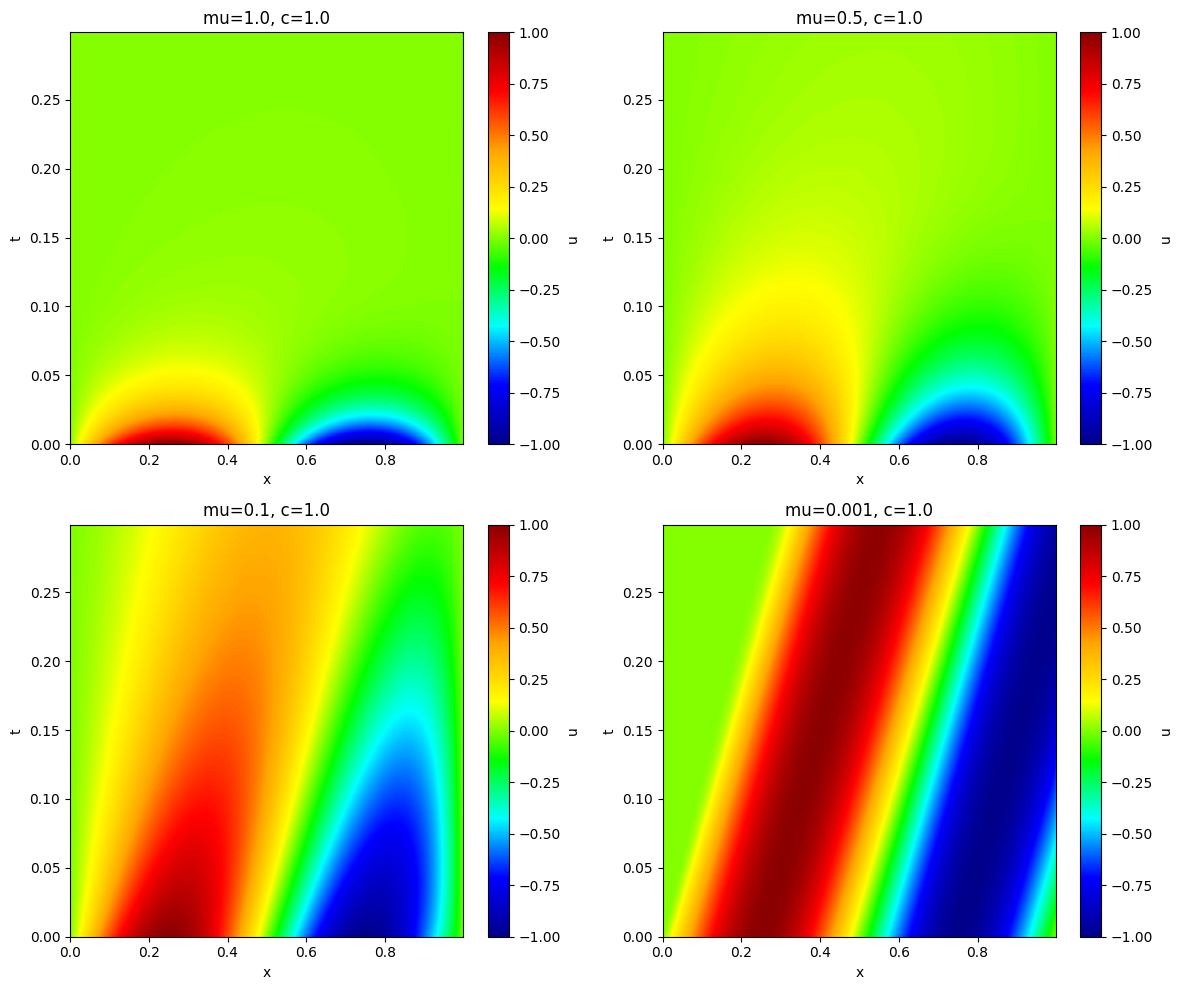

In [116]:
# исследуем поведение численного решения в зависимости от mu

mu_arr = [1.0, 0.5, 0.1, 0.001]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes_flat = axes.flatten()

for idx, mu_curr in enumerate(mu_arr):
    problem14 = BurgersProblem(U0t=U0t, ULt=ULt, Ux0=Ux0, T=T, L=L, c=c, mu=mu_curr)
    burgersSolver = BurgersSolver(problem14)
    h_curr = h

    if mu_curr < 0.1:
        h_curr = h * 0.1

    u = burgersSolver.solve(tau, h_curr)
    exact_u = get_exact_u1(tau, h_curr, T, L, c, mu_curr)
    print_max_diff(exact_u, u, tau, h_curr)
    
    plot_heatmap(u, x, t, title=f'mu={mu_curr}, c={c}', cmap="thermal", ax=axes_flat[idx])

plt.tight_layout()
plt.show()

Max diff: 0.06475873059465255  at point (t: 0.024 , x: 0.0998 )
Max diff: 0.013484125130631332  at point (t: 0.012 , x: 0.0998 )
Max diff: 0.011663802365732341  at point (t: 0.002 , x: 0.0998 )
Max diff: 0.011551372246493349  at point (t: 0.002 , x: 0.0998 )


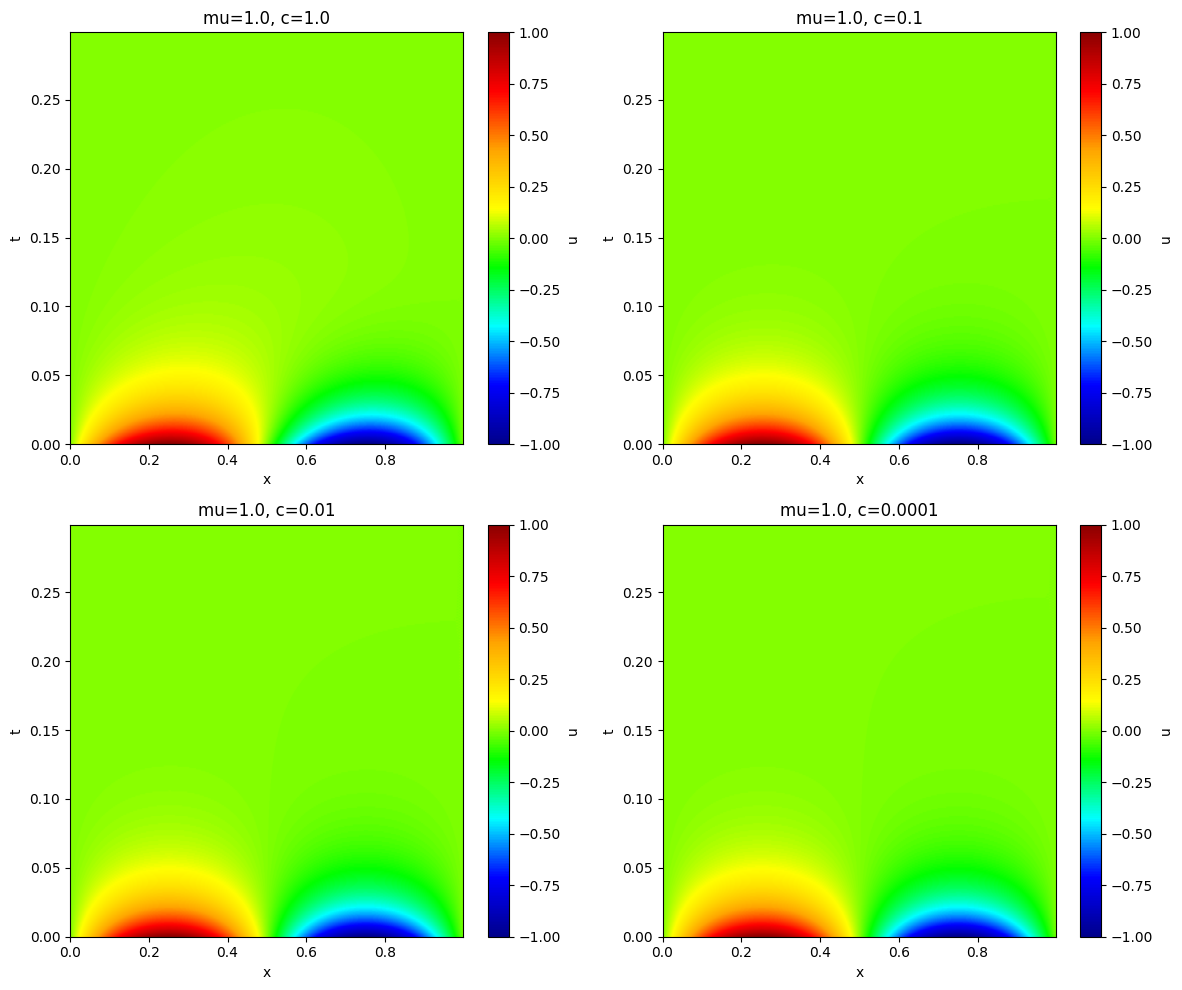

In [117]:
# исследуем поведение численного решения в зависимости от c

c_arr = [1.0, 0.1, 0.01, 0.0001]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes_flat = axes.flatten()

for idx, c_curr in enumerate(c_arr):
    problem14 = BurgersProblem(U0t=U0t, ULt=ULt, Ux0=Ux0, T=T, L=L, c=c_curr, mu=mu)
    burgersSolver = BurgersSolver(problem14)
    u = burgersSolver.solve(tau, h)
    
    exact_u = get_exact_u1(tau, h, T, L, c_curr, mu)
    print_max_diff(exact_u, u, tau, h_curr)
    
    plot_heatmap(u, x, t, title=f'mu={mu}, c={c_curr}', cmap="thermal", ax=axes_flat[idx])

plt.tight_layout()
plt.show()